3# exploration.ipynb
Loads saved model + data and provides tools for graph and prediction exploration.

**Run order:** cells 1–3 are required setup. All others are self-contained.


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch_geometric.nn import SAGEConv
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import spearmanr
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
BASE = "data/processed"

features_norm = np.load(f"{BASE}/features.npy")
targets       = np.load(f"{BASE}/targets_ranked.npy")
train_idx     = np.load(f"{BASE}/train_idx.npy")
val_idx       = np.load(f"{BASE}/val_idx.npy")
test_idx      = np.load(f"{BASE}/test_idx.npy")
edge_indices  = np.load(f"{BASE}/edge_indices.npy", allow_pickle=True)
edge_weights  = np.load(f"{BASE}/edge_weights.npy", allow_pickle=True)
tickers       = pd.read_csv(f"{BASE}/tickers.csv").iloc[:, 0].tolist()
feature_names = pd.read_csv(f"{BASE}/feature_names.csv").iloc[:, 0].tolist()
dates         = pd.to_datetime(pd.read_csv(f"{BASE}/dates.csv").iloc[:, 0])

N_FEATURES = features_norm.shape[2]
N_STOCKS   = features_norm.shape[1]
N_TOTAL    = features_norm.shape[0]

print(f"features : {features_norm.shape}   (T, N, F)")
print(f"targets  : {targets.shape}")
print(f"dates    : {dates.iloc[0].date()}  →  {dates.iloc[-1].date()}")
print(f"tickers  : {N_STOCKS}")
print(f"features : {feature_names}")


features : (2003, 462, 15)   (T, N, F)
targets  : (2003, 462)
dates    : 2015-12-30  →  2025-12-01
tickers  : 462
features : ['roll_mean_5', 'roll_mean_20', 'roll_std_5', 'roll_std_20', 'mom_12_1', 'mom_6_1', 'mom_3_1', 'mom_1_0', 'reversal_1w', 'sharpe_20', 'sharpe_60', 'rel_strength_20', 'rel_strength_60', 'vol_weighted_mom_5', 'vol_weighted_mom_20']


In [3]:
class StockGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers, dropout):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.output  = nn.Linear(hidden_channels, out_channels)
        self.dropout = nn.Dropout(dropout)
        self.relu    = nn.ReLU()

    def forward(self, x, edge_index, edge_weight=None):
        for conv in self.convs:
            x = conv(x, edge_index)
            x = self.relu(x)
            x = self.dropout(x)
        return torch.tanh(self.output(x)).squeeze(-1)


model = StockGNN(
    in_channels=N_FEATURES, hidden_channels=32,
    out_channels=1, num_layers=2, dropout=0.2
)
model.load_state_dict(torch.load("models/stock_gnn_best.pt", map_location=device))
model.to(device)
model.eval()
print("Model loaded")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# ── helper: run inference for a single timestep ───────────────────────────────
def predict_t(t):
    x          = torch.tensor(features_norm[t], dtype=torch.float32).to(device)
    edge_index = torch.tensor(edge_indices[t],  dtype=torch.long).to(device)
    with torch.no_grad():
        pred = model(x, edge_index).cpu().numpy()
    return pred

# ── helper: run inference over an index array, return (preds, trues) ─────────
def predict_all(idx):
    preds, trues = [], []
    for t in idx:
        preds.append(predict_t(t))
        trues.append(targets[t])
    return np.array(preds), np.array(trues)

# ── pre-run val set predictions (used by many cells below) ───────────────────
val_preds, val_trues = predict_all(val_idx)
print(f"Val predictions shape: {val_preds.shape}")


Model loaded
Parameters: 3,105
Val predictions shape: (240, 462)


## 1 · Graph structure

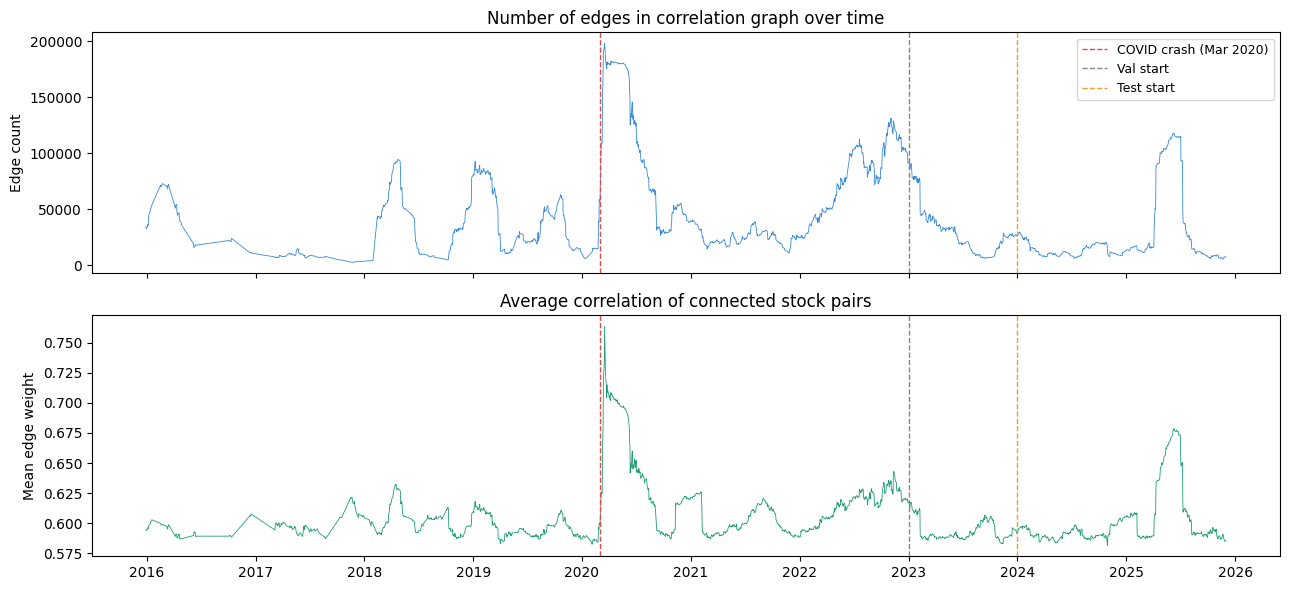

Peak edges : 198,322  on  2020-03-17
Min edges  : 2,760  on  2017-11-20


In [14]:
# ── Edge density and average weight over time ─────────────────────────────────
edge_counts = np.array([edge_indices[t].shape[1] for t in range(N_TOTAL)])
avg_weights = np.array([
    edge_weights[t].mean() if len(edge_weights[t]) > 0 else 0.0
    for t in range(N_TOTAL)
])

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(dates, edge_counts, linewidth=0.6, color="#378ADD")
axes[0].axvline(pd.Timestamp("2020-03-01"), color="#E24B4A", lw=1, ls="--", label="COVID crash (Mar 2020)")
axes[0].axvline(pd.Timestamp("2023-01-01"), color="#888780", lw=1, ls="--", label="Val start")
axes[0].axvline(pd.Timestamp("2024-01-01"), color="#EF9F27", lw=1, ls="--", label="Test start")
axes[0].set_ylabel("Edge count")
axes[0].set_title("Number of edges in correlation graph over time")
axes[0].legend(fontsize=9)

axes[1].plot(dates, avg_weights, linewidth=0.6, color="#1D9E75")
axes[1].axvline(pd.Timestamp("2020-03-01"), color="#E24B4A", lw=1, ls="--")
axes[1].axvline(pd.Timestamp("2023-01-01"), color="#888780", lw=1, ls="--")
axes[1].axvline(pd.Timestamp("2024-01-01"), color="#EF9F27", lw=1, ls="--")
axes[1].set_ylabel("Mean edge weight")
axes[1].set_title("Average correlation of connected stock pairs")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()
print(f"Peak edges : {edge_counts.max():,}  on  {dates.iloc[int(np.argmax(edge_counts))].date()}")
print(f"Min edges  : {edge_counts[edge_counts > 0].min():,}  on  {dates.iloc[int(np.argmin(edge_counts + (edge_counts==0)*999999))].date()}")


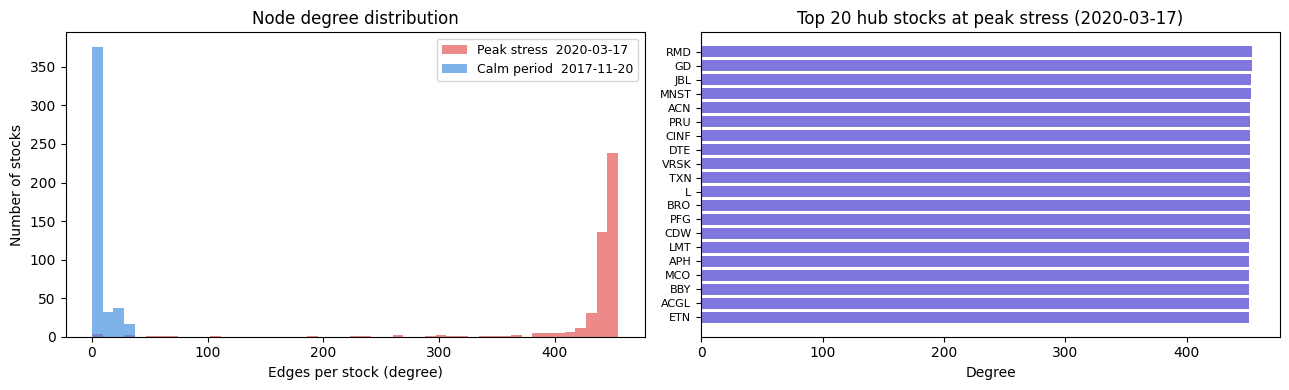

In [15]:
# ── Degree distribution — stress vs calm snapshot ─────────────────────────────
degree_matrix = np.zeros((N_TOTAL, N_STOCKS), dtype=np.int32)
for t in range(N_TOTAL):
    if edge_indices[t].shape[1] > 0:
        np.add.at(degree_matrix[t], edge_indices[t][0], 1)

peak_t = int(np.argmax(edge_counts))
calm_t = int(np.argmin(edge_counts + (edge_counts == 0) * 999999))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# histogram
bins = np.linspace(0, degree_matrix[peak_t].max() + 1, 50)
axes[0].hist(degree_matrix[peak_t], bins=bins, alpha=0.65, color="#E24B4A",
             label=f"Peak stress  {dates.iloc[peak_t].date()}")
axes[0].hist(degree_matrix[calm_t], bins=bins, alpha=0.65, color="#378ADD",
             label=f"Calm period  {dates.iloc[calm_t].date()}")
axes[0].set_xlabel("Edges per stock (degree)")
axes[0].set_ylabel("Number of stocks")
axes[0].set_title("Node degree distribution")
axes[0].legend(fontsize=9)

# top 20 hubs at peak stress
top20 = np.argsort(degree_matrix[peak_t])[-20:][::-1]
axes[1].barh(range(20), degree_matrix[peak_t][top20], color="#7F77DD")
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([tickers[i] for i in top20], fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xlabel("Degree")
axes[1].set_title(f"Top 20 hub stocks at peak stress ({dates.iloc[peak_t].date()})")

plt.tight_layout()
plt.show()


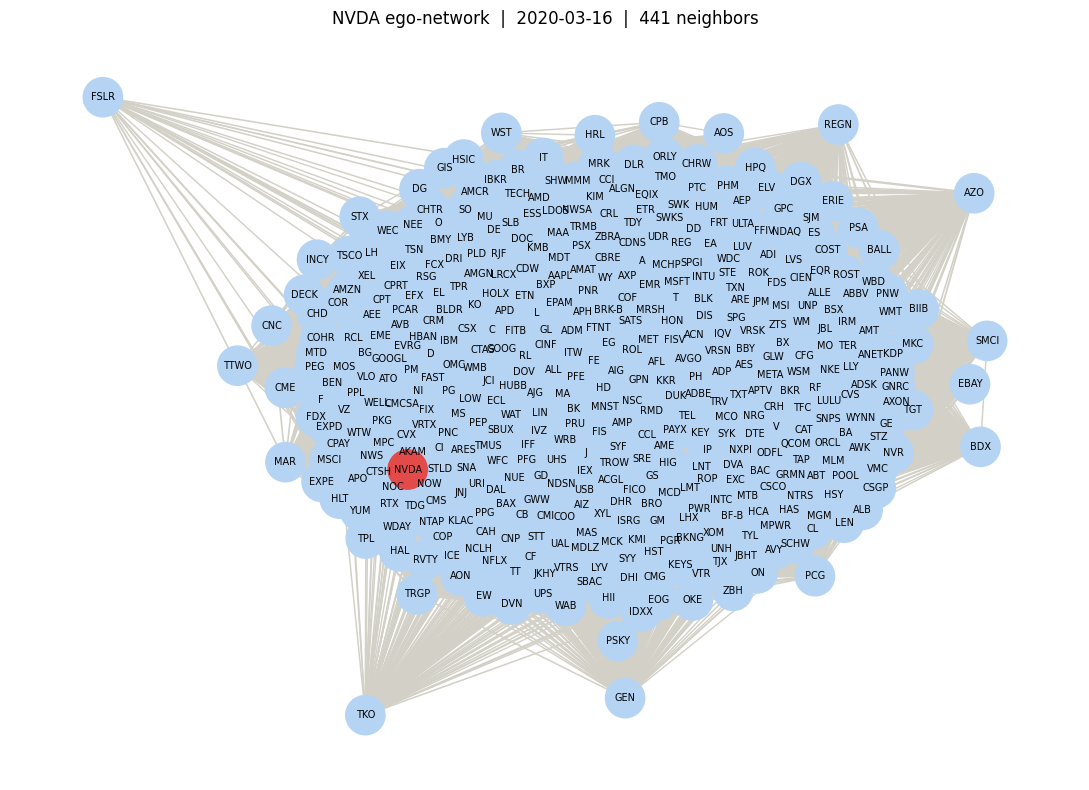

Degree of NVDA on 2020-03-16: 441


In [6]:
# ── Subgraph visualisation ────────────────────────────────────────────────────
# Draws the ego-network of one stock at a given date.
# Change FOCAL_STOCK or TARGET_DATE to explore.

FOCAL_STOCK = "NVDA"
TARGET_DATE = "2020-03-15"   # change to any date in YYYY-MM-DD

t = int(np.argmin(np.abs(dates - pd.Timestamp(TARGET_DATE))))
s = tickers.index(FOCAL_STOCK)

ei  = edge_indices[t]
ew  = edge_weights[t]

# find all neighbors of FOCAL_STOCK
mask       = (ei[0] == s) | (ei[1] == s)
nbr_nodes  = set(ei[0][mask].tolist() + ei[1][mask].tolist()) - {s}
sub_nodes  = list(nbr_nodes) + [s]

# build networkx graph from those nodes
G = nx.Graph()
G.add_nodes_from(sub_nodes)
for i in range(ei.shape[1]):
    u, v = int(ei[0, i]), int(ei[1, i])
    if u in nbr_nodes and v in nbr_nodes:
        G.add_edge(u, v, weight=float(ew[i]))
    elif u == s or v == s:
        G.add_edge(u, v, weight=float(ew[i]))

node_labels = {n: tickers[n] for n in G.nodes()}
node_colors = ["#E24B4A" if n == s else "#B5D4F4" for n in G.nodes()]
edge_widths = [G[u][v]["weight"] * 2 for u, v in G.edges()]

pos = nx.spring_layout(G, seed=42, k=1.5)
fig, ax = plt.subplots(figsize=(11, 8))
nx.draw_networkx(G, pos=pos, labels=node_labels, node_color=node_colors,
                 edge_color="#D3D1C7", width=edge_widths,
                 node_size=800, font_size=7, ax=ax)
ax.set_title(f"{FOCAL_STOCK} ego-network  |  {dates.iloc[t].date()}  |  {len(nbr_nodes)} neighbors",
             fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.show()
print(f"Degree of {FOCAL_STOCK} on {dates.iloc[t].date()}: {len(nbr_nodes)}")


## 2 · Prediction quality

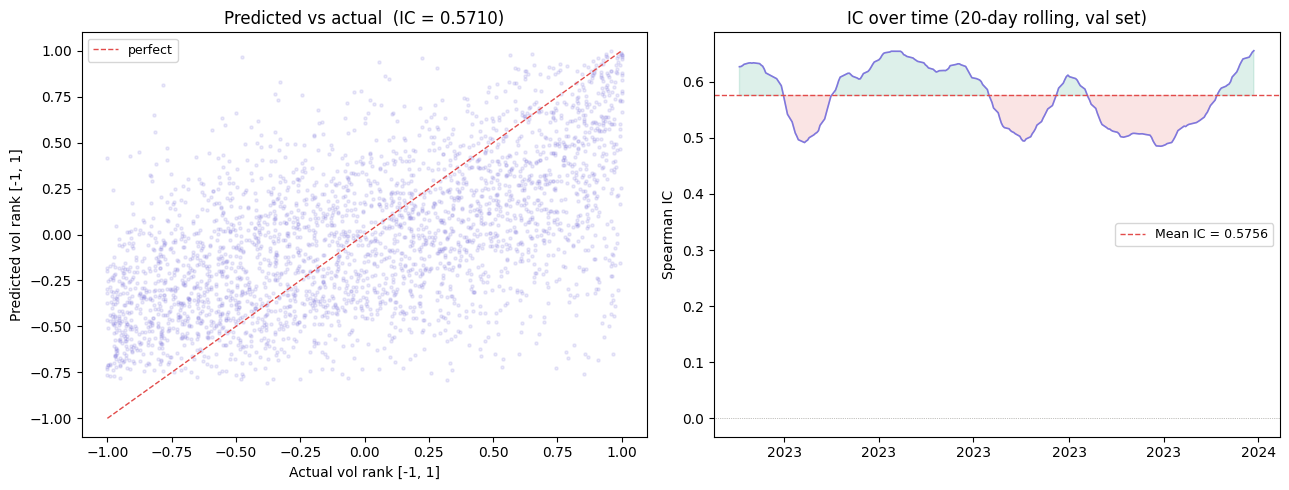

In [7]:
# ── Predicted vs actual scatter + rolling IC ──────────────────────────────────
all_p = val_preds.flatten()
all_t = val_trues.flatten()
rng   = np.random.default_rng(42)
s_idx = rng.choice(len(all_p), size=3000, replace=False)

ic_ts  = np.array([spearmanr(val_preds[i], val_trues[i])[0] for i in range(len(val_idx))])
window = 20
ic_smooth = np.convolve(ic_ts, np.ones(window) / window, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# scatter
axes[0].scatter(all_t[s_idx], all_p[s_idx], alpha=0.15, s=5, color="#7F77DD")
axes[0].plot([-1, 1], [-1, 1], color="#E24B4A", lw=1, ls="--", label="perfect")
axes[0].set_xlabel("Actual vol rank [-1, 1]")
axes[0].set_ylabel("Predicted vol rank [-1, 1]")
overall_ic = spearmanr(all_p, all_t)[0]
axes[0].set_title(f"Predicted vs actual  (IC = {overall_ic:.4f})")
axes[0].legend(fontsize=9)

# rolling IC
smooth_dates = dates.iloc[val_idx].values[window - 1:]
axes[1].plot(smooth_dates, ic_smooth, color="#7F77DD", lw=1.2)
axes[1].axhline(np.nanmean(ic_ts), color="#E24B4A", lw=1, ls="--",
                label=f"Mean IC = {np.nanmean(ic_ts):.4f}")
axes[1].axhline(0, color="#888780", lw=0.5, ls=":")
axes[1].fill_between(smooth_dates, ic_smooth, np.nanmean(ic_ts),
                     where=ic_smooth > np.nanmean(ic_ts),
                     alpha=0.15, color="#1D9E75")
axes[1].fill_between(smooth_dates, ic_smooth, np.nanmean(ic_ts),
                     where=ic_smooth < np.nanmean(ic_ts),
                     alpha=0.15, color="#E24B4A")
axes[1].set_title(f"IC over time ({window}-day rolling, val set)")
axes[1].set_ylabel("Spearman IC")
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()


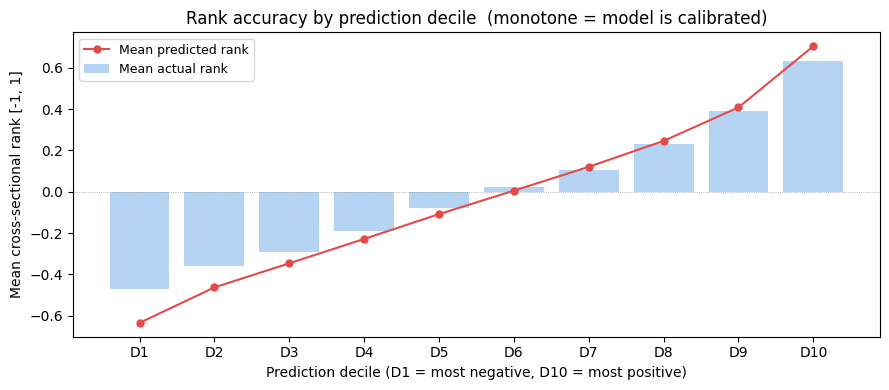

In [8]:
# ── Rank accuracy by prediction decile ───────────────────────────────────────
# For each prediction decile, what is the average actual rank?
# A good model should show a monotone relationship.

all_p_flat = val_preds.flatten()
all_t_flat = val_trues.flatten()

decile_labels, avg_actual, avg_pred = [], [], []
for d in range(10):
    lo = np.percentile(all_p_flat, d * 10)
    hi = np.percentile(all_p_flat, (d + 1) * 10)
    mask = (all_p_flat >= lo) & (all_p_flat < hi)
    if mask.sum() > 0:
        decile_labels.append(f"D{d+1}")
        avg_pred.append(all_p_flat[mask].mean())
        avg_actual.append(all_t_flat[mask].mean())

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(decile_labels))
ax.bar(x, avg_actual, color="#B5D4F4", label="Mean actual rank")
ax.plot(x, avg_pred, color="#E24B4A", marker="o", ms=5, lw=1.5, label="Mean predicted rank")
ax.axhline(0, color="#888780", lw=0.5, ls=":")
ax.set_xticks(list(x))
ax.set_xticklabels(decile_labels)
ax.set_xlabel("Prediction decile (D1 = most negative, D10 = most positive)")
ax.set_ylabel("Mean cross-sectional rank [-1, 1]")
ax.set_title("Rank accuracy by prediction decile  (monotone = model is calibrated)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 3 · Stress-period analysis

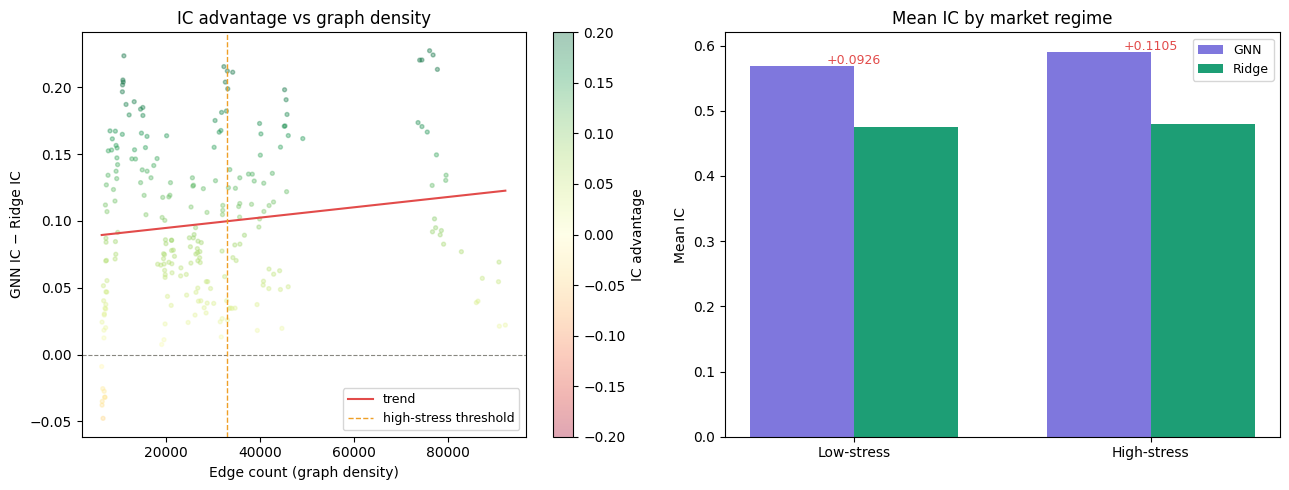

Low-stress  — GNN: 0.5682  Ridge: 0.4756  Advantage: +0.0926
High-stress — GNN: 0.5907  Ridge: 0.4803  Advantage: +0.1105


In [9]:
# ── GNN vs Ridge IC advantage vs graph density ────────────────────────────────
from sklearn.linear_model import Ridge as RidgeReg

ridge = RidgeReg(alpha=1.0)
ridge.fit(
    features_norm[train_idx].reshape(-1, N_FEATURES),
    targets[train_idx].reshape(-1)
)

val_edge_counts = np.array([edge_indices[t].shape[1] for t in val_idx])
gnn_ic_ts       = np.array([spearmanr(val_preds[i], val_trues[i])[0]
                             for i in range(len(val_idx))])
ridge_ic_ts     = np.array([spearmanr(ridge.predict(features_norm[t]), targets[t])[0]
                             for t in val_idx])
ic_advantage    = gnn_ic_ts - ridge_ic_ts

# tercile split
tercile     = np.percentile(val_edge_counts, 67)
high_stress = val_edge_counts >= tercile
low_stress  = ~high_stress

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# scatter
sc = axes[0].scatter(val_edge_counts, ic_advantage, alpha=0.35, s=8,
                     c=ic_advantage, cmap="RdYlGn", vmin=-0.2, vmax=0.2)
z    = np.polyfit(val_edge_counts, ic_advantage, 1)
xfit = np.linspace(val_edge_counts.min(), val_edge_counts.max(), 100)
axes[0].plot(xfit, np.polyval(z, xfit), color="#E24B4A", lw=1.5, label="trend")
axes[0].axhline(0, color="#888780", lw=0.8, ls="--")
axes[0].axvline(tercile, color="#EF9F27", lw=1, ls="--", label="high-stress threshold")
axes[0].set_xlabel("Edge count (graph density)")
axes[0].set_ylabel("GNN IC − Ridge IC")
axes[0].set_title("IC advantage vs graph density")
axes[0].legend(fontsize=9)
plt.colorbar(sc, ax=axes[0], label="IC advantage")

# bar chart: mean IC by regime
regimes    = ["Low-stress", "High-stress"]
gnn_means  = [gnn_ic_ts[low_stress].mean(),  gnn_ic_ts[high_stress].mean()]
ridge_means= [ridge_ic_ts[low_stress].mean(), ridge_ic_ts[high_stress].mean()]
x = np.arange(2)
w = 0.35
axes[1].bar(x - w/2, gnn_means,   w, color="#7F77DD", label="GNN")
axes[1].bar(x + w/2, ridge_means, w, color="#1D9E75", label="Ridge")
for i in range(2):
    axes[1].annotate(f"+{gnn_means[i]-ridge_means[i]:.4f}",
                     xy=(i, max(gnn_means[i], ridge_means[i]) + 0.003),
                     ha="center", fontsize=9, color="#E24B4A")
axes[1].set_xticks(x)
axes[1].set_xticklabels(regimes)
axes[1].set_ylabel("Mean IC")
axes[1].set_title("Mean IC by market regime")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

for label, mask in [("Low-stress ", low_stress), ("High-stress", high_stress)]:
    print(f"{label} — GNN: {gnn_ic_ts[mask].mean():.4f}  "
          f"Ridge: {ridge_ic_ts[mask].mean():.4f}  "
          f"Advantage: +{(gnn_ic_ts - ridge_ic_ts)[mask].mean():.4f}")


## 4 · Individual stock exploration

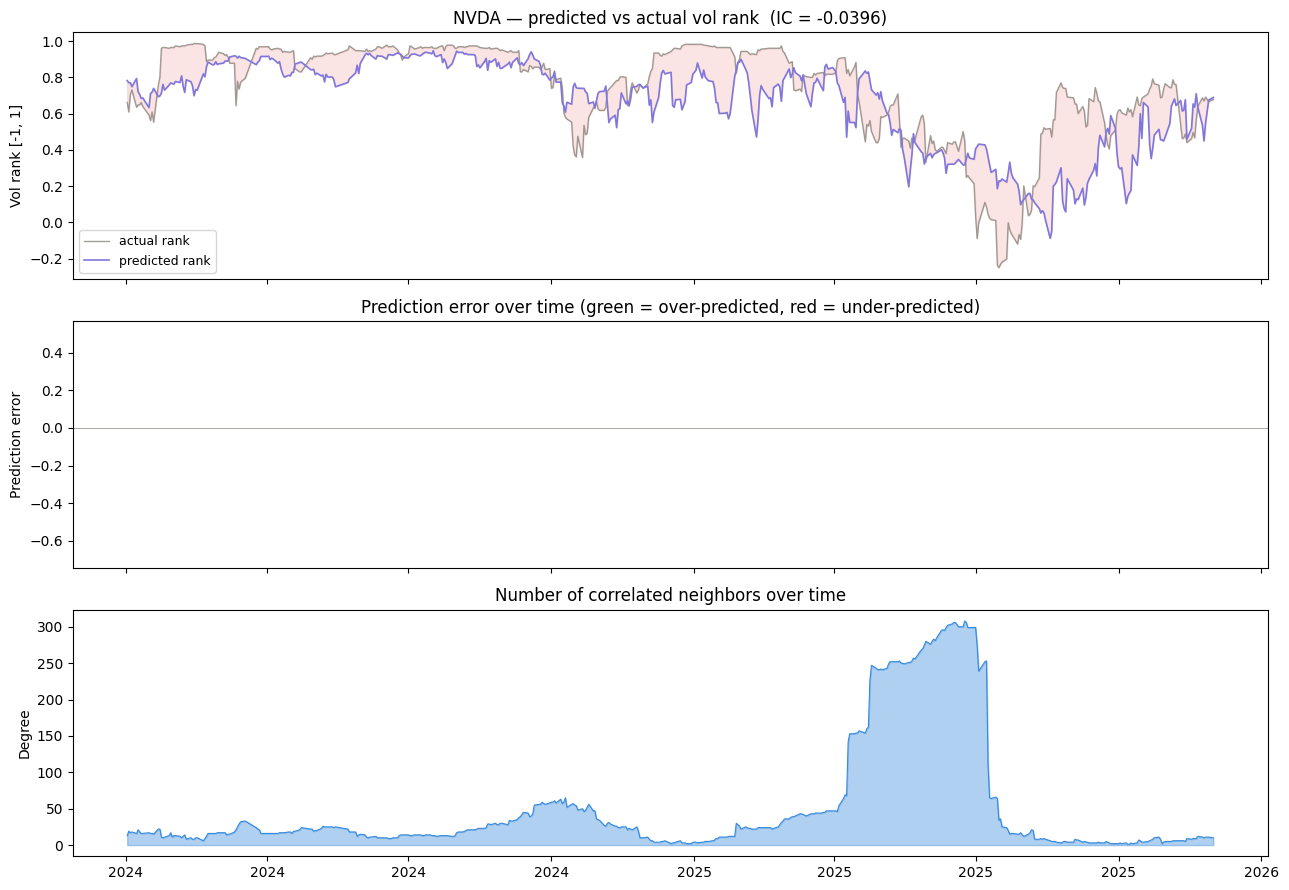


NVDA summary (val set):
  IC:             -0.0396
  Mean error:     -0.0757
  Mean degree:    50.5


IndexError: index 356 is out of bounds for axis 0 with size 240

In [16]:
# ── Single stock deep-dive ────────────────────────────────────────────────────
# Change STOCK to any ticker in the universe.

STOCK = "NVDA"
s_idx = tickers.index(STOCK)

test_preds, test_trues = predict_all(test_idx)
s_pred = test_preds[:, s_idx]
s_true = test_trues[:, s_idx]
s_dates  = dates.iloc[test_idx].values
s_degree = np.array([degree_matrix[t][s_idx] for t in test_idx])

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# predicted vs actual rank
axes[0].plot(s_dates, s_true, color="#888780", lw=1,   label="actual rank",    alpha=0.8)
axes[0].plot(s_dates, s_pred, color="#7F77DD", lw=1.2, label="predicted rank")
axes[0].fill_between(s_dates, s_true, s_pred, alpha=0.15, color="#E24B4A")
axes[0].set_ylabel("Vol rank [-1, 1]")
axes[0].set_title(f"{STOCK} — predicted vs actual vol rank  (IC = {s_ic:.4f})")
axes[0].legend(fontsize=9)

# prediction error
error = s_pred - s_true
axes[1].bar(s_dates, error, color=np.where(error > 0, "#1D9E75", "#E24B4A"),
            width=1, alpha=0.6)
axes[1].axhline(0, color="#888780", lw=0.5)
axes[1].set_ylabel("Prediction error")
axes[1].set_title("Prediction error over time (green = over-predicted, red = under-predicted)")

# degree over time
axes[2].fill_between(s_dates, s_degree, alpha=0.4, color="#378ADD")
axes[2].plot(s_dates, s_degree, color="#378ADD", lw=0.8)
axes[2].set_ylabel("Degree")
axes[2].set_title(f"Number of correlated neighbors over time")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

print(f"\n{STOCK} summary (val set):")
print(f"  IC:             {s_ic:.4f}")
print(f"  Mean error:     {error.mean():.4f}")
print(f"  Mean degree:    {s_degree.mean():.1f}")
print(f"  Peak degree:    {s_degree.max()} on {dates.iloc[val_idx[int(np.argmax(s_degree))]].date()}")


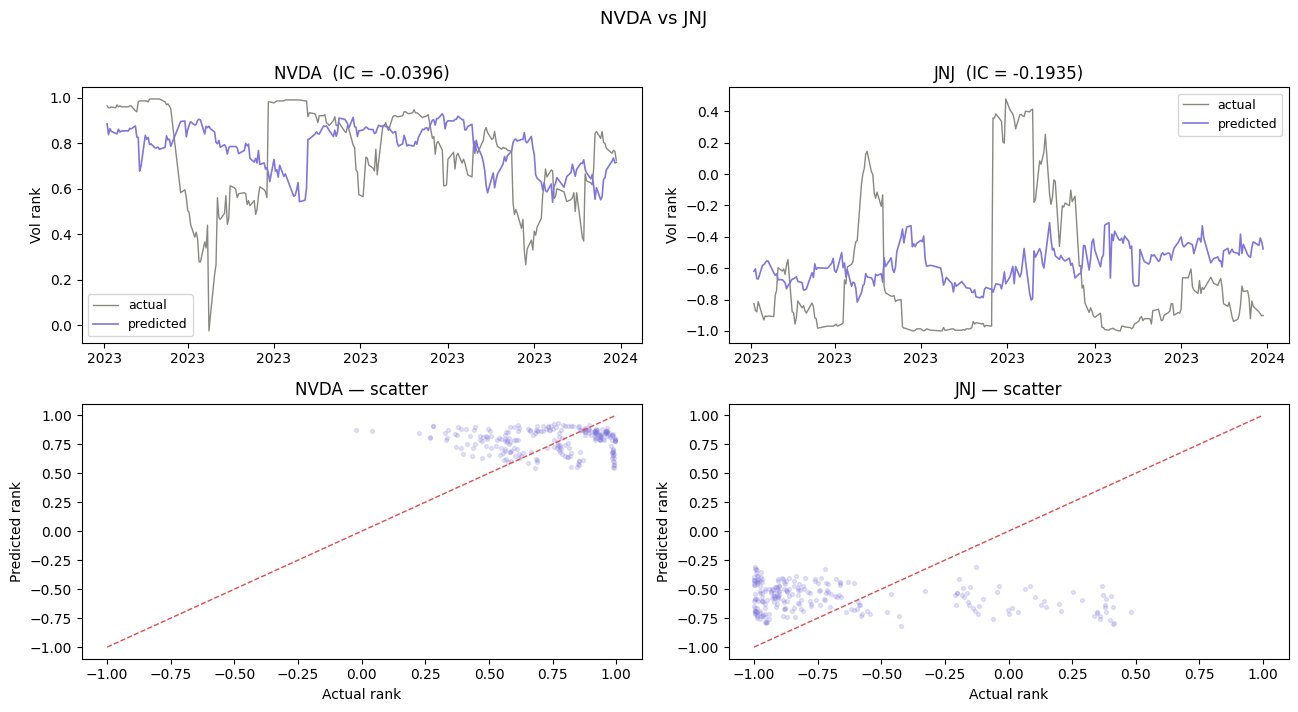

In [11]:
# ── Compare two stocks head-to-head ──────────────────────────────────────────
STOCK_A = "NVDA"
STOCK_B = "JNJ"

for stock in [STOCK_A, STOCK_B]:
    if stock not in tickers:
        print(f"WARNING: {stock} not in universe")

idx_a = tickers.index(STOCK_A)
idx_b = tickers.index(STOCK_B)
s_dates = dates.iloc[val_idx].values

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

for col, (stock, idx) in enumerate([(STOCK_A, idx_a), (STOCK_B, idx_b)]):
    pred = val_preds[:, idx]
    true = val_trues[:, idx]
    ic, _ = spearmanr(pred, true)

    axes[0, col].plot(s_dates, true, color="#888780", lw=1, label="actual")
    axes[0, col].plot(s_dates, pred, color="#7F77DD", lw=1.2, label="predicted")
    axes[0, col].set_title(f"{stock}  (IC = {ic:.4f})")
    axes[0, col].set_ylabel("Vol rank")
    axes[0, col].legend(fontsize=9)
    axes[0, col].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    axes[1, col].scatter(true, pred, alpha=0.2, s=8, color="#7F77DD")
    axes[1, col].plot([-1, 1], [-1, 1], color="#E24B4A", lw=1, ls="--")
    axes[1, col].set_xlabel("Actual rank")
    axes[1, col].set_ylabel("Predicted rank")
    axes[1, col].set_title(f"{stock} — scatter")

plt.suptitle(f"{STOCK_A} vs {STOCK_B}", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


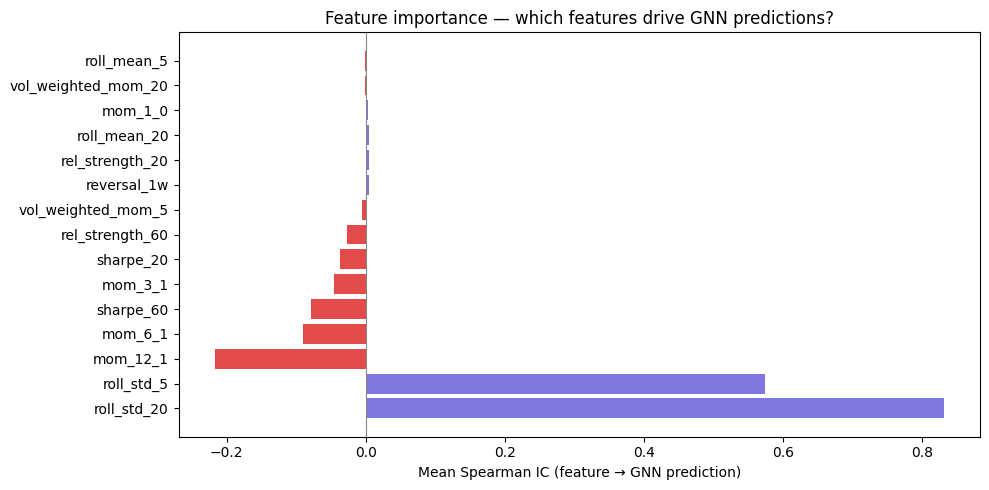

Top 5 features by |IC|:
  1. roll_std_20                IC = 0.8307
  2. roll_std_5                 IC = 0.5736
  3. mom_12_1                   IC = -0.2168
  4. mom_6_1                    IC = -0.0898
  5. sharpe_60                  IC = -0.0783


In [12]:
# ── Feature importance — correlation of each feature to model predictions ─────
# At each timestep, how correlated is each feature (cross-sectionally) to
# the model's predictions? High correlation = feature drives predictions.

n_val    = len(val_idx)
feat_ic  = np.zeros((n_val, N_FEATURES))

for i, t in enumerate(val_idx):
    pred = val_preds[i]
    for f in range(N_FEATURES):
        feat_vals = features_norm[t, :, f]
        feat_ic[i, f], _ = spearmanr(feat_vals, pred)

mean_feat_ic = np.nanmean(feat_ic, axis=0)
order = np.argsort(np.abs(mean_feat_ic))[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#7F77DD" if v >= 0 else "#E24B4A" for v in mean_feat_ic[order]]
ax.barh(range(N_FEATURES), mean_feat_ic[order], color=colors)
ax.set_yticks(range(N_FEATURES))
ax.set_yticklabels([feature_names[i] for i in order], fontsize=10)
ax.axvline(0, color="#888780", lw=0.8)
ax.set_xlabel("Mean Spearman IC (feature → GNN prediction)")
ax.set_title("Feature importance — which features drive GNN predictions?")
plt.tight_layout()
plt.show()

print("Top 5 features by |IC|:")
for rank, i in enumerate(order[:5]):
    print(f"  {rank+1}. {feature_names[i]:<25}  IC = {mean_feat_ic[i]:.4f}")


In [13]:
# ── Test set evaluation ────────────────────────────────────────────────────────
# Run once you're happy with the model — this is the held-out result.

test_preds, test_trues = predict_all(test_idx)

all_p = test_preds.flatten()
all_t = test_trues.flatten()
test_mse = np.mean((all_p - all_t) ** 2)
test_ic, _ = spearmanr(all_p, all_t)
baseline_mse = np.mean(all_t ** 2)

print("─── Test set results ────────────────────────────────")
print(f"  MSE:              {test_mse:.6f}")
print(f"  Baseline MSE:     {baseline_mse:.6f}")
print(f"  Improvement:      {(baseline_mse - test_mse) / baseline_mse * 100:.2f}%")
print(f"  IC (Spearman):    {test_ic:.4f}")
print(f"  Pred range:       [{all_p.min():.3f}, {all_p.max():.3f}]")

ic_by_t = np.array([spearmanr(test_preds[i], test_trues[i])[0]
                    for i in range(len(test_idx))])
print(f"  IC std:           {np.nanstd(ic_by_t):.4f}")
print(f"  % timesteps IC>0: {(ic_by_t > 0).mean() * 100:.1f}%")


─── Test set results ────────────────────────────────
  MSE:              0.224499
  Baseline MSE:     0.334780
  Improvement:      32.94%
  IC (Spearman):    0.5812
  Pred range:       [-0.902, 1.000]
  IC std:           0.0748
  % timesteps IC>0: 100.0%
